In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
crime_stats_df = pd.read_csv("total_df (1).csv", encoding = 'utf-8')

In [ ]:
crime_stats_df.head(3)

,region,강도,살인,성범죄,절도,폭력,cctv_count,경찰서,파출소 및 지구대
0,서울 종로구,5,1,208,1180,1360,1223.0,2.0,20.0
1,서울 중구,5,5,180,1410,1378,1191.0,2.0,15.0
2,서울 용산구,4,10,262,1072,1941,1930.0,1.0,7.0


In [ ]:
crime_cols = ['강도', '살인', '성범죄', '절도', '폭력']
infra_cols = ['cctv_count', '경찰서', '파출소 및 지구대']

use_cols = crime_cols + infra_cols

crime_stats_df[use_cols] = crime_stats_df[use_cols].fillna(0)

crime_stats_df['crime_count'] = crime_stats_df[crime_cols].sum(axis=1)
crime_stats_df['infra_count'] = crime_stats_df[infra_cols].sum(axis=1)

In [ ]:
crime_stats_df[crime_stats_df.isna().any(axis=1)]

,region,강도,살인,성범죄,절도,폭력,cctv_count,경찰서,파출소 및 지구대,crime_count,infra_count


In [ ]:
crime_stats_df

,region,강도,살인,성범죄,절도,폭력,cctv_count,경찰서,파출소 및 지구대,crime_count,infra_count
0,서울 종로구,5,1,208,1180,1360,1223.0,2.0,20.0,2754,1245.0
1,서울 중구,5,5,180,1410,1378,1191.0,2.0,15.0,2978,1208.0
2,서울 용산구,4,10,262,1072,1941,1930.0,1.0,7.0,3289,1938.0
3,서울 성동구,2,5,114,968,1033,1314.0,1.0,9.0,2122,1324.0
4,서울 광진구,6,2,237,1321,1303,1304.0,1.0,10.0,2869,1315.0
...,...,...,...,...,...,...,...,...,...,...,...
224,경남 함양군,0,0,9,63,110,1179.0,1.0,7.0,182,1187.0
225,경남 산청군,0,2,8,45,97,953.0,1.0,5.0,152,959.0
226,경남 의령군,0,0,7,40,126,329.0,1.0,7.0,173,337.0
227,제주 서귀포시,5,4,91,791,1230,681.0,1.0,9.0,2121,691.0


In [ ]:
# 위험도 점수 산출 방식

# 점수 정규화
scaler = MinMaxScaler()

crime_stats_df['crime_score'] = scaler.fit_transform(crime_stats_df[['crime_count']]) * 100
crime_stats_df['CCTV_score'] = scaler.fit_transform(crime_stats_df[['cctv_count']]) * 100
crime_stats_df['infra_score'] = scaler.fit_transform(crime_stats_df[['infra_count']]) * 100

In [ ]:
# 위험도 점수 계산

crime_stats_df['risk_score'] = (
    crime_stats_df['crime_score'] * 0.95 -
    crime_stats_df['CCTV_score'] * 0.03 -
    crime_stats_df['infra_score'] * 0.02
)

# 위험도점수 최소 5, 최대 100점
crime_stats_df['risk_score'] = crime_stats_df['risk_score'].clip(5, 100).round(1)

crime_stats_df['safety_score'] = (100 - crime_stats_df['risk_score'].round(1))

crime_stats_df[['region', 'crime_score', 'CCTV_score', 'infra_score', 'risk_score', 'safety_score']].head(3)

,region,crime_score,CCTV_score,infra_score,risk_score,safety_score
0,서울 종로구,25.248306,7.796264,7.880643,23.6,76.4
1,서울 중구,27.327578,7.592274,7.644733,25.6,74.4
2,서울 용산구,30.214425,12.303181,12.299158,28.1,71.9


In [ ]:
# 위험도 등급 분류 기준

def classify_risk(score) :
    if score < 20 :
        return '매우낮음'
    elif score < 40 :
        return '낮음'
    elif score < 60 :
        return '보통'
    elif score < 80 :
        return '높음'
    else :
        return '매우높음'

crime_stats_df['risk_level'] = crime_stats_df['risk_score'].apply(classify_risk)

crime_stats_df[['region', 'crime_count', 'risk_score', 'risk_level']]

,region,crime_count,risk_score,risk_level
0,서울 종로구,2754,23.6,낮음
1,서울 중구,2978,25.6,낮음
2,서울 용산구,3289,28.1,낮음
3,서울 성동구,2122,18.0,매우낮음
4,서울 광진구,2869,24.6,낮음
...,...,...,...,...
224,경남 함양군,182,5.0,매우낮음
225,경남 산청군,152,5.0,매우낮음
226,경남 의령군,173,5.0,매우낮음
227,제주 서귀포시,2121,18.2,매우낮음


In [ ]:
# 범죄 발생 패턴 분석

# 범죄 유형별 비율
# crime_cols에서 하나씩 꺼내
for col in crime_cols :
    # 범죄 유형에 _비율을 붙여 컬럼 추가, 각 범죄를 총범죄로 나누어 비율 계산
    crime_stats_df[col + '_비율'] = (crime_stats_df[col] / crime_stats_df['crime_count'] * 100).round(1)

# 상위 3개 범죄 유형 추출

def get_top_crimes(row) :
    # 행에서 crime_cols 열만 선택, 값을 내림차순으로 정렬, 상위 3개 선택
    top3 = row[crime_cols] \
    .sort_values(ascending = False) \
    .head(3)

    return ', '.join(top3.index.tolist())

crime_stats_df['major_crime_type'] = crime_stats_df.apply(get_top_crimes, axis = 1)

crime_stats_df[['region', 'major_crime_type', '절도_비율', '폭력_비율', '성범죄_비율', '강도_비율', '살인_비율']]

,region,major_crime_type,절도_비율,폭력_비율,성범죄_비율,강도_비율,살인_비율
0,서울 종로구,"폭력, 절도, 성범죄",42.8,49.4,7.6,0.2,0.0
1,서울 중구,"절도, 폭력, 성범죄",47.3,46.3,6.0,0.2,0.2
2,서울 용산구,"폭력, 절도, 성범죄",32.6,59.0,8.0,0.1,0.3
3,서울 성동구,"폭력, 절도, 성범죄",45.6,48.7,5.4,0.1,0.2
4,서울 광진구,"절도, 폭력, 성범죄",46.0,45.4,8.3,0.2,0.1
...,...,...,...,...,...,...,...
224,경남 함양군,"폭력, 절도, 성범죄",34.6,60.4,4.9,0.0,0.0
225,경남 산청군,"폭력, 절도, 성범죄",29.6,63.8,5.3,0.0,1.3
226,경남 의령군,"폭력, 절도, 성범죄",23.1,72.8,4.0,0.0,0.0
227,제주 서귀포시,"폭력, 절도, 성범죄",37.3,58.0,4.3,0.2,0.2


In [ ]:
!apt-get update -qq
!apt-get install -y fonts-nanum
!fc-cache -fv

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 7 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped direc

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

fm.fontManager.addfont(font_path)
mpl.rcParams['font.family'] = 'NanumGothic'
mpl.rcParams['axes.unicode_minus'] = False

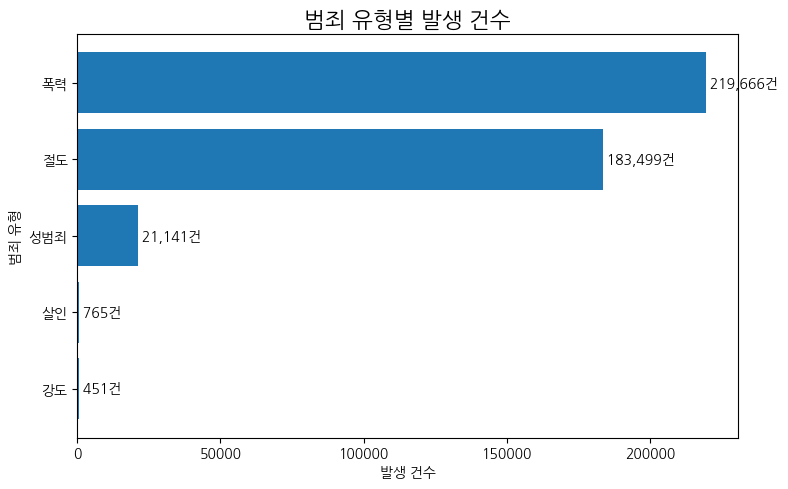

In [ ]:
crime_cols = ['강도', '살인', '성범죄', '절도', '폭력']

crime_sum = crime_stats_df[crime_cols].sum().sort_values(ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(crime_sum.index, crime_sum.values)

plt.title('범죄 유형별 발생 건수', fontsize=16, fontweight='bold')
plt.xlabel('발생 건수')
plt.ylabel('범죄 유형')

for i, v in enumerate(crime_sum.values):
    plt.text(v, i, f' {int(v):,}건', va='center', fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_4217/854456431.py:19: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4217/854456431.py:19: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4217/854456431.py:19: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4217/854456431.py:19: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4217/854456431.py:19: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4217/854456431.py:19: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4217/854456431.py:19: UserWarning: Glyph 49332 (\N{HANGUL SYLLABLE SAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout

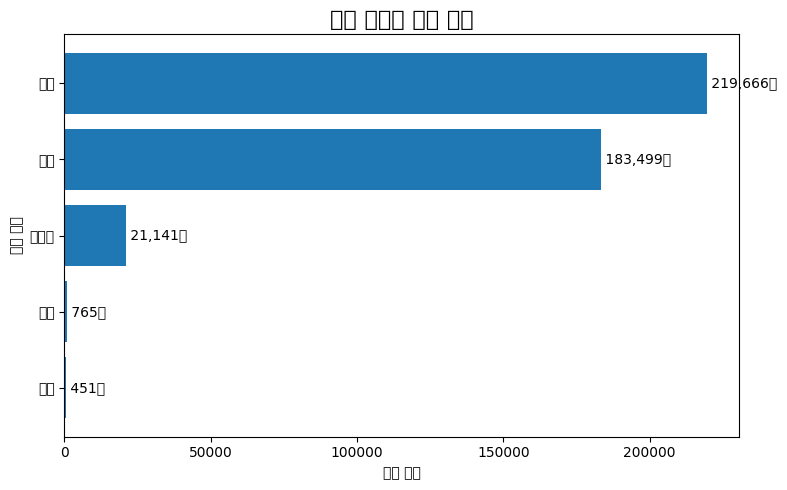

In [ ]:
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

crime_cols = ['강도', '살인', '성범죄', '절도', '폭력']

# 전체 범죄 유형별 합계
crime_sum = crime_stats_df[crime_cols].sum().sort_values(ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(crime_sum.index, crime_sum.values)

plt.title('범죄 유형별 발생 건수', fontsize=16, fontweight='bold')
plt.xlabel('발생 건수')
plt.ylabel('범죄 유형')

for i, v in enumerate(crime_sum.values):
    plt.text(v, i, f' {int(v):,}건', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
crime_stats_df[crime_stats_df.isna().any(axis = 1)]

,region,강도,살인,성범죄,절도,폭력,cctv_count,경찰서,파출소 및 지구대,crime_count,...,risk_score,safety_score,risk_level,강도_비율,살인_비율,성범죄_비율,절도_비율,폭력_비율,major_crime_type,cluster


In [ ]:
# K-Means 군집화

# 수도권 / 지방권 차이가 커서 로그변환
crime_stats_df['crime_count_log'] = np.log1p(
    crime_stats_df['crime_count']
)

crime_stats_df['cctv_log'] = np.log1p(
    crime_stats_df['cctv_count']
)

crime_stats_df['infra_log'] = np.log1p(
    crime_stats_df['infra_count']
)
features = crime_stats_df[
    ['crime_count_log', 'cctv_log', 'infra_log']
]

# 표준화 객체 - 평균 0, 표준편차 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# 10번 수행한 뒤 가장 좋은 값 1개를 선택해 3개의 그룹으로 나눈다.
kmeans = KMeans(n_clusters = 3, random_state = 42, n_init = 10)

# 데이터를 보고 군집기준 학습 후 클러스터 배정
crime_stats_df['cluster'] = kmeans.fit_predict(X_scaled)
crime_stats_df.head()

,region,강도,살인,성범죄,절도,폭력,cctv_count,경찰서,파출소 및 지구대,crime_count,...,강도_비율,살인_비율,성범죄_비율,절도_비율,폭력_비율,major_crime_type,crime_count_log,cctv_log,infra_log,cluster
0,서울 종로구,5,1,208,1180,1360,1223.0,2.0,20.0,2754,...,0.2,0.0,7.6,42.8,49.4,"폭력, 절도, 성범죄",7.921173,7.109879,7.127694,0
1,서울 중구,5,5,180,1410,1378,1191.0,2.0,15.0,2978,...,0.2,0.2,6.0,47.3,46.3,"절도, 폭력, 성범죄",7.999343,7.083388,7.097549,0
2,서울 용산구,4,10,262,1072,1941,1930.0,1.0,7.0,3289,...,0.1,0.3,8.0,32.6,59.0,"폭력, 절도, 성범죄",8.098643,7.565793,7.569928,0
3,서울 성동구,2,5,114,968,1033,1314.0,1.0,9.0,2122,...,0.1,0.2,5.4,45.6,48.7,"폭력, 절도, 성범죄",7.660585,7.181592,7.189168,0
4,서울 광진구,6,2,237,1321,1303,1304.0,1.0,10.0,2869,...,0.2,0.1,8.3,46.0,45.4,"절도, 폭력, 성범죄",7.962067,7.173958,7.182352,0


In [ ]:
# 클러스터 해석

# 클러스터 번호가 같은것끼리 그룹화
cluster_summary = crime_stats_df.groupby('cluster')[
    # 해당 열만 선택
    ['crime_count', 'cctv_count', 'infra_count', 'risk_score']
# 평균 계산
].mean().round(1)

cluster_summary

,crime_count,cctv_count,infra_count,risk_score
cluster,,,,
0,2896.5,2270.8,2282.5,24.6
1,382.4,784.4,792.1,5.4
2,2734.8,40.8,53.3,23.8


In [ ]:
cluster_labels = {
    0: '범죄 집중 관리 지역',
    1: '생활 안전 지역',
    2: '치안 인프라 보완 필요 지역'
}
crime_stats_df['region_type'] = crime_stats_df['cluster'].map(cluster_labels)

In [ ]:
# 검증

# 상위 위험 지역
crime_stats_df.sort_values(
    by = 'risk_score',
    ascending = False
)[['region', 'risk_score']].head(10)

,region,risk_score
87,경기도 수원시,93.4
215,경남 창원시,72.0
85,경기도 부천시,68.4
126,충북 청주시,63.3
86,경기도 성남시,62.8
89,경기도 안산시,58.8
103,경기도 화성시,58.4
76,경기도 고양시,58.1
95,경기도 용인시,57.6
143,충남 천안시,55.3


In [ ]:
# 실루엣 점수 - 같은 그룹끼리 잘 모여있고, 다른 그룹끼리 잘 떨어져있는가 평가 - 군집화 품질 평가 점수

score = silhouette_score(
    # 군집화에 사용한 데이터
    X_scaled,
    # 실제 예측한 클러스터 번호
    crime_stats_df['cluster']
)

print(score)

0.48924786806382753


In [ ]:
crime_stats_df[
    crime_stats_df['region'].str.contains('대구')
].sort_values(
    by='risk_score',
    ascending=False
)[['region', 'risk_score']]

,region,risk_score
47,대구 달서구,37.0
34,부산 해운대구,27.8
45,대구 북구,27.5
42,대구 동구,25.9
46,대구 수성구,21.1
41,대구 중구,20.3
43,대구 서구,16.3
48,대구 달성군,14.8
44,대구 남구,12.8
49,대구 군위군,5.0


In [ ]:
result_df = crime_stats_df[['region', '강도', '살인', '성범죄', '절도', '폭력',
                            'major_crime_type', '절도_비율', '폭력_비율', '성범죄_비율', '강도_비율', '살인_비율',
                            'crime_count', 'risk_score', 'cluster', 'region_type']]

result_df

,region,강도,살인,성범죄,절도,폭력,major_crime_type,절도_비율,폭력_비율,성범죄_비율,강도_비율,살인_비율,crime_count,risk_score,cluster,region_type
0,서울 종로구,5,1,208,1180,1360,"폭력, 절도, 성범죄",42.8,49.4,7.6,0.2,0.0,2754,23.6,0,범죄 집중 관리 지역
1,서울 중구,5,5,180,1410,1378,"절도, 폭력, 성범죄",47.3,46.3,6.0,0.2,0.2,2978,25.6,0,범죄 집중 관리 지역
2,서울 용산구,4,10,262,1072,1941,"폭력, 절도, 성범죄",32.6,59.0,8.0,0.1,0.3,3289,28.1,0,범죄 집중 관리 지역
3,서울 성동구,2,5,114,968,1033,"폭력, 절도, 성범죄",45.6,48.7,5.4,0.1,0.2,2122,18.0,0,범죄 집중 관리 지역
4,서울 광진구,6,2,237,1321,1303,"절도, 폭력, 성범죄",46.0,45.4,8.3,0.2,0.1,2869,24.6,0,범죄 집중 관리 지역
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224,경남 함양군,0,0,9,63,110,"폭력, 절도, 성범죄",34.6,60.4,4.9,0.0,0.0,182,5.0,1,생활 안전 지역
225,경남 산청군,0,2,8,45,97,"폭력, 절도, 성범죄",29.6,63.8,5.3,0.0,1.3,152,5.0,1,생활 안전 지역
226,경남 의령군,0,0,7,40,126,"폭력, 절도, 성범죄",23.1,72.8,4.0,0.0,0.0,173,5.0,1,생활 안전 지역
227,제주 서귀포시,5,4,91,791,1230,"폭력, 절도, 성범죄",37.3,58.0,4.3,0.2,0.2,2121,18.2,0,범죄 집중 관리 지역


In [ ]:
result_df.to_csv(
    'crime_stats.csv',
    encoding = 'utf-8-sig'
)

In [ ]:
crime_stats_df[crime_stats_df['cluster'] == 2]

,region,강도,살인,성범죄,절도,폭력,cctv_count,경찰서,파출소 및 지구대,crime_count,...,살인_비율,성범죄_비율,절도_비율,폭력_비율,major_crime_type,cluster,crime_count_log,cctv_log,infra_log,region_type
60,광주 동구,0,1,55,560,672,81.0,1.0,5.0,1288,...,0.1,4.3,43.5,52.2,"폭력, 절도, 성범죄",2,7.161622,4.406719,4.477337,치안 인프라 보완 필요 지역
61,광주 서구,7,4,185,1246,1635,51.0,1.0,7.0,3077,...,0.1,6.0,40.5,53.1,"폭력, 절도, 성범죄",2,8.032035,3.951244,4.094345,치안 인프라 보완 필요 지역
62,광주 남구,1,2,58,759,695,79.0,1.0,6.0,1515,...,0.1,3.8,50.1,45.9,"절도, 폭력, 성범죄",2,7.323831,4.382027,4.465908,치안 인프라 보완 필요 지역
74,울산 울주군,2,6,59,507,749,0.0,1.0,10.0,1323,...,0.5,4.5,38.3,56.6,"폭력, 절도, 성범죄",2,7.188413,0.000000,2.484907,치안 인프라 보완 필요 지역
103,경기도 화성시,7,14,262,2895,3483,2.0,2.0,18.0,6661,...,0.2,3.9,43.5,52.3,"폭력, 절도, 성범죄",2,8.804175,1.098612,3.135494,치안 인프라 보완 필요 지역
126,충북 청주시,6,13,299,3788,3113,148.0,3.0,21.0,7219,...,0.2,4.1,52.5,43.1,"절도, 폭력, 성범죄",2,8.884610,5.003946,5.153292,치안 인프라 보완 필요 지역
137,충남 공주시,0,3,43,244,315,6.0,1.0,8.0,605,...,0.5,7.1,40.3,52.1,"폭력, 절도, 성범죄",2,6.406880,1.945910,2.772589,치안 인프라 보완 필요 지역
169,전남 여수시,3,8,91,713,1302,0.0,1.0,18.0,2117,...,0.4,4.3,33.7,61.5,"폭력, 절도, 성범죄",2,7.658228,0.000000,2.995732,치안 인프라 보완 필요 지역
212,경남 사천시,2,4,40,267,495,0.0,1.0,8.0,808,...,0.5,5.0,33.0,61.3,"폭력, 절도, 성범죄",2,6.695799,0.000000,2.302585,치안 인프라 보완 필요 지역
